In [ ]:
%pip install statsmodels matplotlib pandas seaborn

In [ ]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import json
import matplotlib.pyplot as plt



In [ ]:
# Load your cleaned dataset
det = pd.read_csv("detentions_2021_25.csv")

In [ ]:
# Load offense classification (discretionary or serious)
with open("offenses_mapping.json", "r") as f:
    offense_mapping = json.load(f)

In [ ]:
# Map offenses to category (discretionary/serious)
det['discretionary'] = det['offense'].map(lambda x: offense_mapping.get(x, {}).get('discretionary', None))
det['category'] = det['offense'].map(lambda x: offense_mapping.get(x, {}).get('category', None))


In [ ]:
# Drop rows with missing discretionary/category labels
det = det.dropna(subset=['discretionary', 'category'])

In [ ]:
# Create migrant dummy variable
det['migrant_dummy'] = (det['nat'] == 'Venezolana').astype(int)


In [ ]:
# Keep only 2022
det = det[det['year'] == 2022]


In [ ]:
# Define regression formula
formula = 'n_det ~ migrant_dummy * discretionary + C(comuna)'


In [ ]:
# Check for multicollinearity
from patsy import dmatrices
from numpy.linalg import LinAlgError
import numpy as np

y, X = dmatrices(formula, data=det, return_type='dataframe')
try:
    _ = np.linalg.inv(X.T @ X)
    print("Design matrix is invertible.")
except LinAlgError:
    print("Design matrix is singular. Check for collinearity or too many dummy variables.")


In [ ]:
# Fit Poisson regression
model = smf.poisson(formula, data=det).fit()


In [ ]:
model.summary()

In [ ]:
# Save coefficients and standard errors
coeffs = model.params
stderr = model.bse
results = pd.DataFrame({'coefficient': coeffs, 'std_err': stderr})

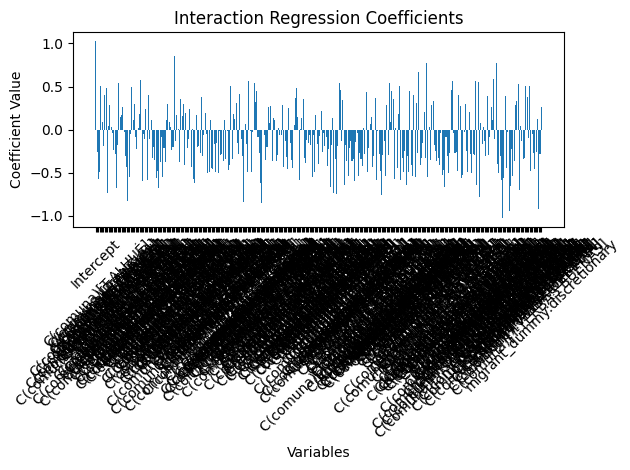

In [18]:
# Plot coefficient for interaction term (discretionary * migrant_dummy)
plt.bar(results.index, results['coefficient'])
plt.title("Interaction Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.xlabel("Variables")
plt.xticks(rotation=45)
plt.tight_layout()

# Save plot as PNG
plt.savefig("fig3_betas.png")


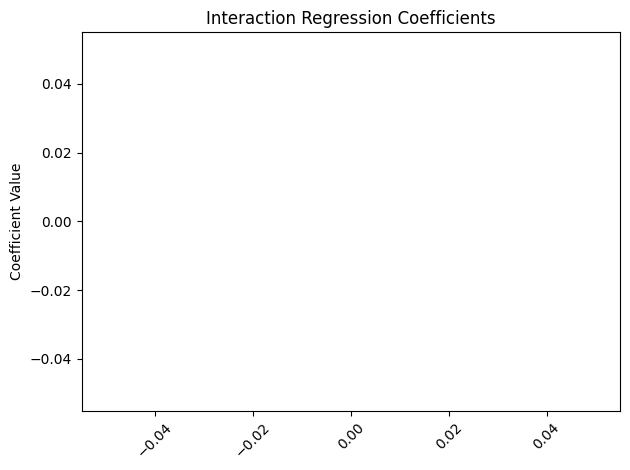

In [19]:
# Focus only on the interaction term coefficient for 'discretionary * migrant_dummy'
interaction_coeff = results.loc[results.index.str.contains("discretionary:migrant_dummy"), "coefficient"]

# Plot it
plt.bar(interaction_coeff.index, interaction_coeff.values, color='blue')
plt.title("Interaction Regression Coefficients")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.tight_layout()

# Save it
plt.savefig("fig3_betas.png")


In [21]:
# Check if 'discretionary:migrant_dummy' is present in model output
print(model.summary())


                          Poisson Regression Results                          
Dep. Variable:                  n_det   No. Observations:               108135
Model:                        Poisson   Df Residuals:                   107788
Method:                           MLE   Df Model:                          346
Date:                Thu, 24 Jul 2025   Pseudo R-squ.:                 0.05984
Time:                        13:48:01   Log-Likelihood:            -3.5825e+05
converged:                       True   LL-Null:                   -3.8105e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             1.0265      0.044     23.402      0.000       0.940       1.112
C(comuna)[T.ALHUÉ]                   -0.2598      0.091     -2